# Monthly recalibration training-window robustness

## Does the two-season training-window assumption drive the result'

The main pooled model uses a previous-two-season training window. This notebook tests whether that researcher choice materially affects the market-efficiency conclusion.

The experiment uses monthly walk-forward recalibration with four prespecified training histories:

- `12M`: rolling previous 12 calendar months
- `18M`: rolling previous 18 calendar months
- `24M`: rolling previous 24 calendar months
- `all_history`: expanding window using all prior matches

This is a robustness test, not a parameter search. The objective is not to select the historically highest-ROI window, but to check whether the conclusion is stable across reasonable recency/sample-size trade-offs.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from football_edge.backtest import (
    build_execution_candidates,
    build_research_dataset,
    monthly_roi,
    probability_performance,
    run_pooled_monthly_recalibration_walk_forward,
    summarize_bets,
)
from football_edge.config import MINIMUM_EXPECTED_VALUE, MODEL_FEATURES, RAW_DATA_DIR
from football_edge.data import discover_datasets

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

WINDOWS = ["12M", "18M", "24M", "all_history"]
WINDOW_LABELS = {
    "12M": "Rolling 12M",
    "18M": "Rolling 18M",
    "24M": "Rolling 24M",
    "all_history": "Expanding all history",
}
WINDOW_COLORS = {
    "12M": "#1B9E77",
    "18M": "#D95F02",
    "24M": "#7570B3",
    "all_history": "#E7298A",
}
SOURCE_ORDER = [
    "bet365",
    "pinnacle",
    "betfair_exchange",
    "average_preclosing",
    "best_preclosing",
    "best_closing",
]
SOURCE_LABELS = {
    "bet365": "Bet365",
    "pinnacle": "Pinnacle",
    "betfair_exchange": "Betfair Exchange",
    "average_preclosing": "Market average",
    "best_preclosing": "Market maximum",
    "best_closing": "Closing maximum*",
}
L2 = 100.0
EV_THRESHOLD = MINIMUM_EXPECTED_VALUE
FINAL_EXECUTION_SOURCE = "best_preclosing"
KEY_COEFFICIENTS = [
    "market_logit",
    "home_last_5_avg_goals",
    "away_last_5_avg_goals",
    "home_season_avg_goals",
    "away_season_avg_goals",
]


def add_zero_line(axis, *, vertical=False):
    if vertical:
        axis.axvline(0, color="black", linewidth=1, alpha=0.8)
    else:
        axis.axhline(0, color="black", linewidth=1, alpha=0.8)


def plot_panel_legend(figure, handles, labels, y=0.985):
    by_label = dict(zip(labels, handles))
    figure.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper center",
        ncol=min(len(by_label), 4),
        frameon=True,
        bbox_to_anchor=(0.5, y),
    )


def ordered_window_frame(frame):
    result = frame.copy()
    result["training_window"] = pd.Categorical(
        result["training_window"], categories=WINDOWS, ordered=True
    )
    return result.sort_values("training_window")

## 1. Experimental design

All assumptions except the training-history window are fixed:

- target: Over 2.5 goals;
- model: pooled market-anchored logistic regression;
- features: the same `MODEL_FEATURES` used by the main pooled model;
- league dummy variables: same pooled design as the main model;
- regularization: `L2 = 100`;
- recalibration: monthly;
- EV threshold: `EV >= 3%`;
- execution sources, commission assumptions, settlement, and CLV calculation: same as the main backtest utilities.

For each prediction month, the model is trained only on matches strictly before the first day of that month. The notebook uses the common overlapping set of prediction months across all windows for the main comparison, so a window is not favored simply because it starts earlier or later.

## 2. Data and feature construction

The notebook reuses the same raw-data discovery, feature engineering, market-implied probability construction, and leakage controls as the rest of the project.

In [2]:
datasets = discover_datasets(RAW_DATA_DIR)
all_matches = build_research_dataset(datasets)

required = [*MODEL_FEATURES, "over_2_5", "league", "season", "date"]
analysis_matches = all_matches.dropna(subset=required).copy()

print(f"Datasets: {len(datasets)}")
print(f"Raw engineered matches: {len(all_matches):,}")
print(f"Model-eligible matches: {len(analysis_matches):,}")
analysis_matches[["date", "league", "season", "home_team", "away_team", *MODEL_FEATURES, "over_2_5"]].head()

Datasets: 20
Raw engineered matches: 7,230
Model-eligible matches: 7,034


,date,league,season,home_team,away_team,market_logit,home_season_avg_goals,away_season_avg_goals,home_last_5_avg_goals,away_last_5_avg_goals,over_2_5
9,2021-08-20 19:30:00,Bundesliga,21_22,RB Leipzig,Stuttgart,0.513454,0.0,5.0,0.0,5.0,1
10,2021-08-21 14:30:00,Bundesliga,21_22,Bochum,Mainz,0.156569,0.0,1.0,0.0,1.0,0
11,2021-08-21 14:30:00,Bundesliga,21_22,Ein Frankfurt,Augsburg,0.447312,2.0,0.0,2.0,0.0,0
12,2021-08-21 14:30:00,Bundesliga,21_22,Freiburg,Dortmund,0.582518,0.0,5.0,0.0,5.0,1
13,2021-08-21 14:30:00,Bundesliga,21_22,Greuther Furth,Bielefeld,-0.078369,1.0,0.0,1.0,0.0,0


## 3. Monthly walk-forward recalibration

Each window is evaluated by the reusable `run_pooled_monthly_recalibration_walk_forward` helper. The helper stores fold metadata and asserts that the latest training date is strictly earlier than the first test date in every monthly fold.

In [3]:
prediction_frames = []
coefficient_frames = []
for window in WINDOWS:
    predictions, coefficients = run_pooled_monthly_recalibration_walk_forward(
        analysis_matches,
        window,
        l2=L2,
        model_name=WINDOW_LABELS[window],
        feature_columns=MODEL_FEATURES,
    )
    prediction_frames.append(predictions)
    coefficient_frames.append(coefficients)

monthly_predictions_full = pd.concat(prediction_frames, ignore_index=True)
monthly_coefficients_full = pd.concat(coefficient_frames, ignore_index=True)

assert (monthly_predictions_full["train_end_date"] < monthly_predictions_full["test_start_date"]).all()
assert monthly_predictions_full["model_probability"].between(0, 1).all()

fold_summary_full = (
    monthly_predictions_full.drop_duplicates(["training_window", "recalibration_month"])
    .groupby("training_window", sort=False)
    .agg(
        recalibration_months=("recalibration_month", "nunique"),
        first_month=("recalibration_month", "min"),
        last_month=("recalibration_month", "max"),
        avg_training_matches=("training_matches", "mean"),
        min_training_matches=("training_matches", "min"),
        max_training_matches=("training_matches", "max"),
        avg_test_matches=("test_matches", "mean"),
    )
    .reset_index()
)
fold_summary_full = ordered_window_frame(fold_summary_full)

common_months = sorted(
    set.intersection(
        *[
            set(
                monthly_predictions_full.loc[
                    monthly_predictions_full["training_window"].eq(window),
                    "recalibration_month",
                ]
            )
            for window in WINDOWS
        ]
    )
)
monthly_predictions = monthly_predictions_full.loc[
    monthly_predictions_full["recalibration_month"].isin(common_months)
].copy()
monthly_coefficients = monthly_coefficients_full.loc[
    monthly_coefficients_full["recalibration_month"].isin(common_months)
].copy()

print(f"Common overlapping recalibration months: {len(common_months)}")
print(f"Common period: {min(common_months):%Y-%m} to {max(common_months):%Y-%m}")
fold_summary_full

Common overlapping recalibration months: 31
Common period: 2023-08 to 2026-05


,training_window,recalibration_months,first_month,last_month,avg_training_matches,min_training_matches,max_training_matches,avg_test_matches
0,12M,42,2022-08-01,2026-05-01,1403.880952,1298,1508,134.000000
1,18M,36,2023-02-01,2026-05-01,2108.305556,1874,2324,136.611111
2,24M,31,2023-08-01,2026-05-01,2814.838710,2711,2908,136.161290
3,all_history,50,2021-10-01,2026-05-01,3530.480000,203,6876,136.620000


## 4. Predictive diagnostics

Predictive diagnostics are evaluated on the common overlapping monthly test period. This prevents a shorter or longer window from looking better because it is evaluated over a different set of months.

In [4]:
predictive_summary = probability_performance(
    monthly_predictions,
    probability_column="model_probability",
    group_by=["training_window"],
)
common_fold_summary = (
    monthly_predictions.drop_duplicates(["training_window", "recalibration_month"])
    .groupby("training_window", sort=False)
    .agg(
        recalibration_months=("recalibration_month", "nunique"),
        avg_training_matches=("training_matches", "mean"),
        avg_test_matches=("test_matches", "mean"),
        total_test_matches=("test_matches", "sum"),
    )
    .reset_index()
)
predictive_summary = common_fold_summary.merge(
    predictive_summary, on="training_window", how="left"
)
predictive_summary = ordered_window_frame(predictive_summary)
predictive_summary

,training_window,recalibration_months,avg_training_matches,avg_test_matches,total_test_matches,observations,brier_score,log_loss,accuracy,calibration_intercept,calibration_slope,mean_probability,event_rate
0,12M,31,1412.354839,136.16129,4221,4221,0.238216,0.669081,0.588249,0.011900,1.030952,0.535392,0.539209
1,18M,31,2092.193548,136.16129,4221,4221,0.237877,0.668360,0.588960,0.013036,1.001575,0.536055,0.539209
2,24M,31,2814.838710,136.16129,4221,4221,0.237697,0.667930,0.587538,0.020944,0.983381,0.534741,0.539209
3,all_history,31,4780.967742,136.16129,4221,4221,0.237428,0.667383,0.593935,0.035423,0.972892,0.531549,0.539209


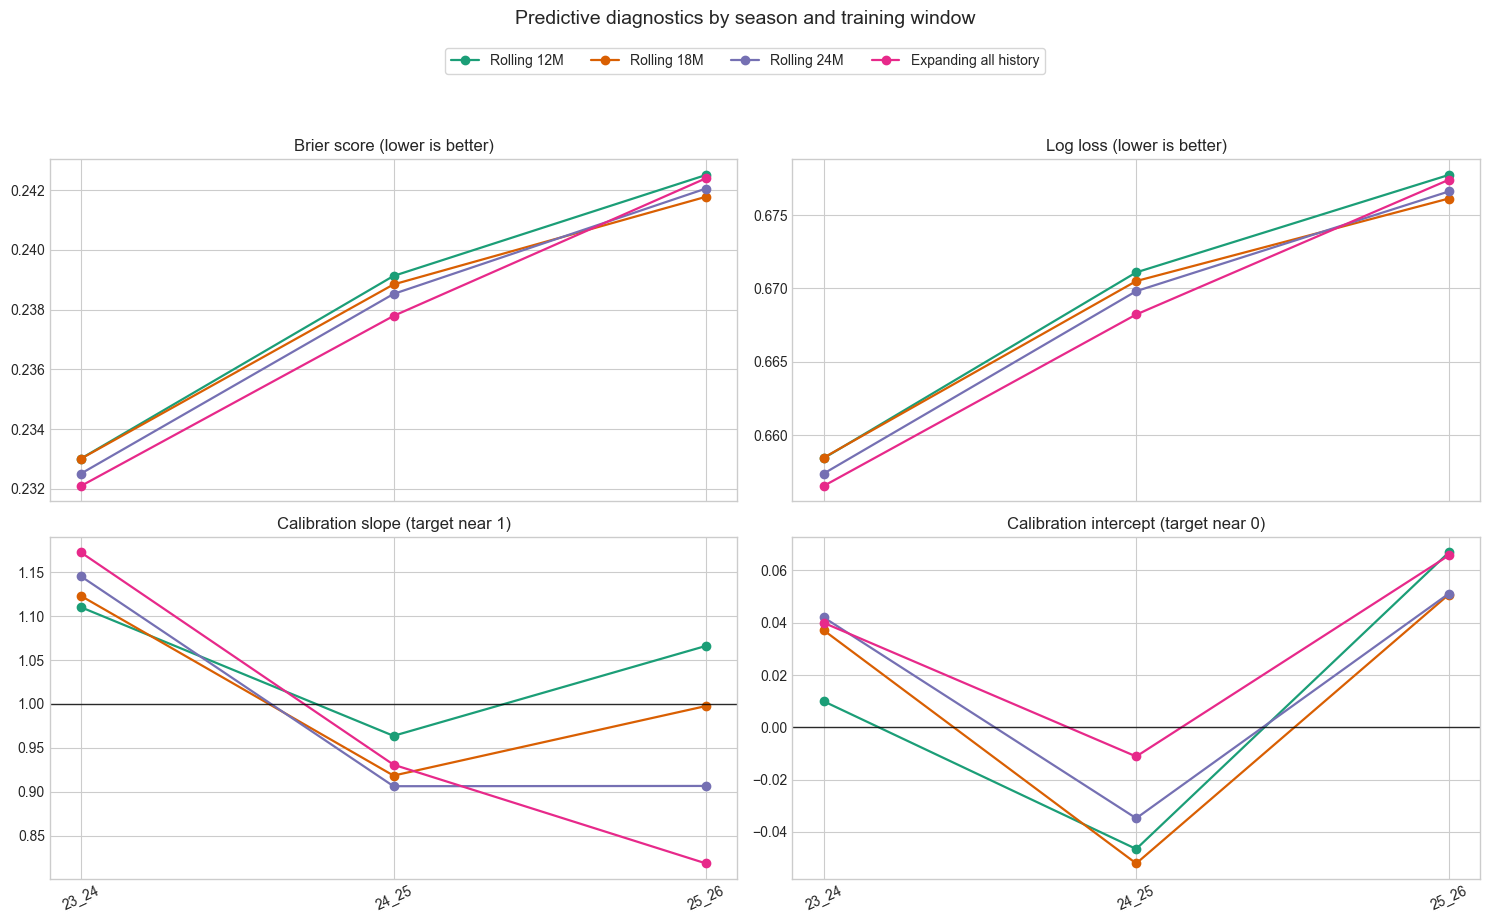

In [5]:
metrics_to_plot = {
    "brier_score": "Brier score (lower is better)",
    "log_loss": "Log loss (lower is better)",
    "calibration_slope": "Calibration slope (target near 1)",
    "calibration_intercept": "Calibration intercept (target near 0)",
}
seasonal_predictive = probability_performance(
    monthly_predictions,
    probability_column="model_probability",
    group_by=["training_window", "season"],
)
season_order = sorted(monthly_predictions["season"].unique())

figure, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
axes = axes.ravel()
handles, labels = [], []
for axis, (metric, title) in zip(axes, metrics_to_plot.items()):
    for window in WINDOWS:
        subset = seasonal_predictive.loc[seasonal_predictive["training_window"].eq(window)]
        line = axis.plot(
            subset["season"],
            subset[metric],
            marker="o",
            linewidth=1.6,
            color=WINDOW_COLORS[window],
            label=WINDOW_LABELS[window],
        )[0]
        handles.append(line)
        labels.append(WINDOW_LABELS[window])
    if metric == "calibration_slope":
        axis.axhline(1, color="black", linewidth=1, alpha=0.8)
    if metric == "calibration_intercept":
        add_zero_line(axis)
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=25)
plot_panel_legend(figure, handles, labels, y=0.985)
figure.suptitle("Predictive diagnostics by season and training window", y=1.02, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 5. Coefficient stability

Monthly recalibration creates many coefficient estimates. Stable windows should show coherent coefficient paths, especially for `market_logit`, while short rolling windows may adapt faster at the cost of noisier coefficients.

In [6]:
coefficient_subset = monthly_coefficients.loc[
    monthly_coefficients["coefficient"].isin(KEY_COEFFICIENTS)
].copy()
coefficient_stability = (
    coefficient_subset.groupby(["training_window", "coefficient"], sort=True)
    .agg(
        folds=("value", "size"),
        mean_coefficient=("value", "mean"),
        std_coefficient=("value", "std"),
        positive_share=("value", lambda values: values.gt(0).mean()),
    )
    .reset_index()
)
coefficient_stability["sign_stability"] = coefficient_stability["positive_share"].map(
    lambda share: max(share, 1 - share)
)
coefficient_stability = ordered_window_frame(coefficient_stability)
coefficient_stability

,training_window,coefficient,folds,mean_coefficient,std_coefficient,positive_share,sign_stability
0,12M,away_last_5_avg_goals,31,-0.007093,0.033899,0.516129,0.516129
1,12M,away_season_avg_goals,31,0.052164,0.042930,0.870968,0.870968
2,12M,home_last_5_avg_goals,31,-0.019337,0.018877,0.161290,0.838710
3,12M,home_season_avg_goals,31,0.069662,0.018092,1.000000,1.000000
4,12M,market_logit,31,0.305756,0.045297,1.000000,1.000000
8,18M,home_season_avg_goals,31,0.062049,0.024864,0.935484,0.935484
7,18M,home_last_5_avg_goals,31,-0.029100,0.018467,0.064516,0.935484
9,18M,market_logit,31,0.346182,0.028226,1.000000,1.000000
5,18M,away_last_5_avg_goals,31,-0.016262,0.032069,0.354839,0.645161
6,18M,away_season_avg_goals,31,0.052105,0.037984,0.935484,0.935484


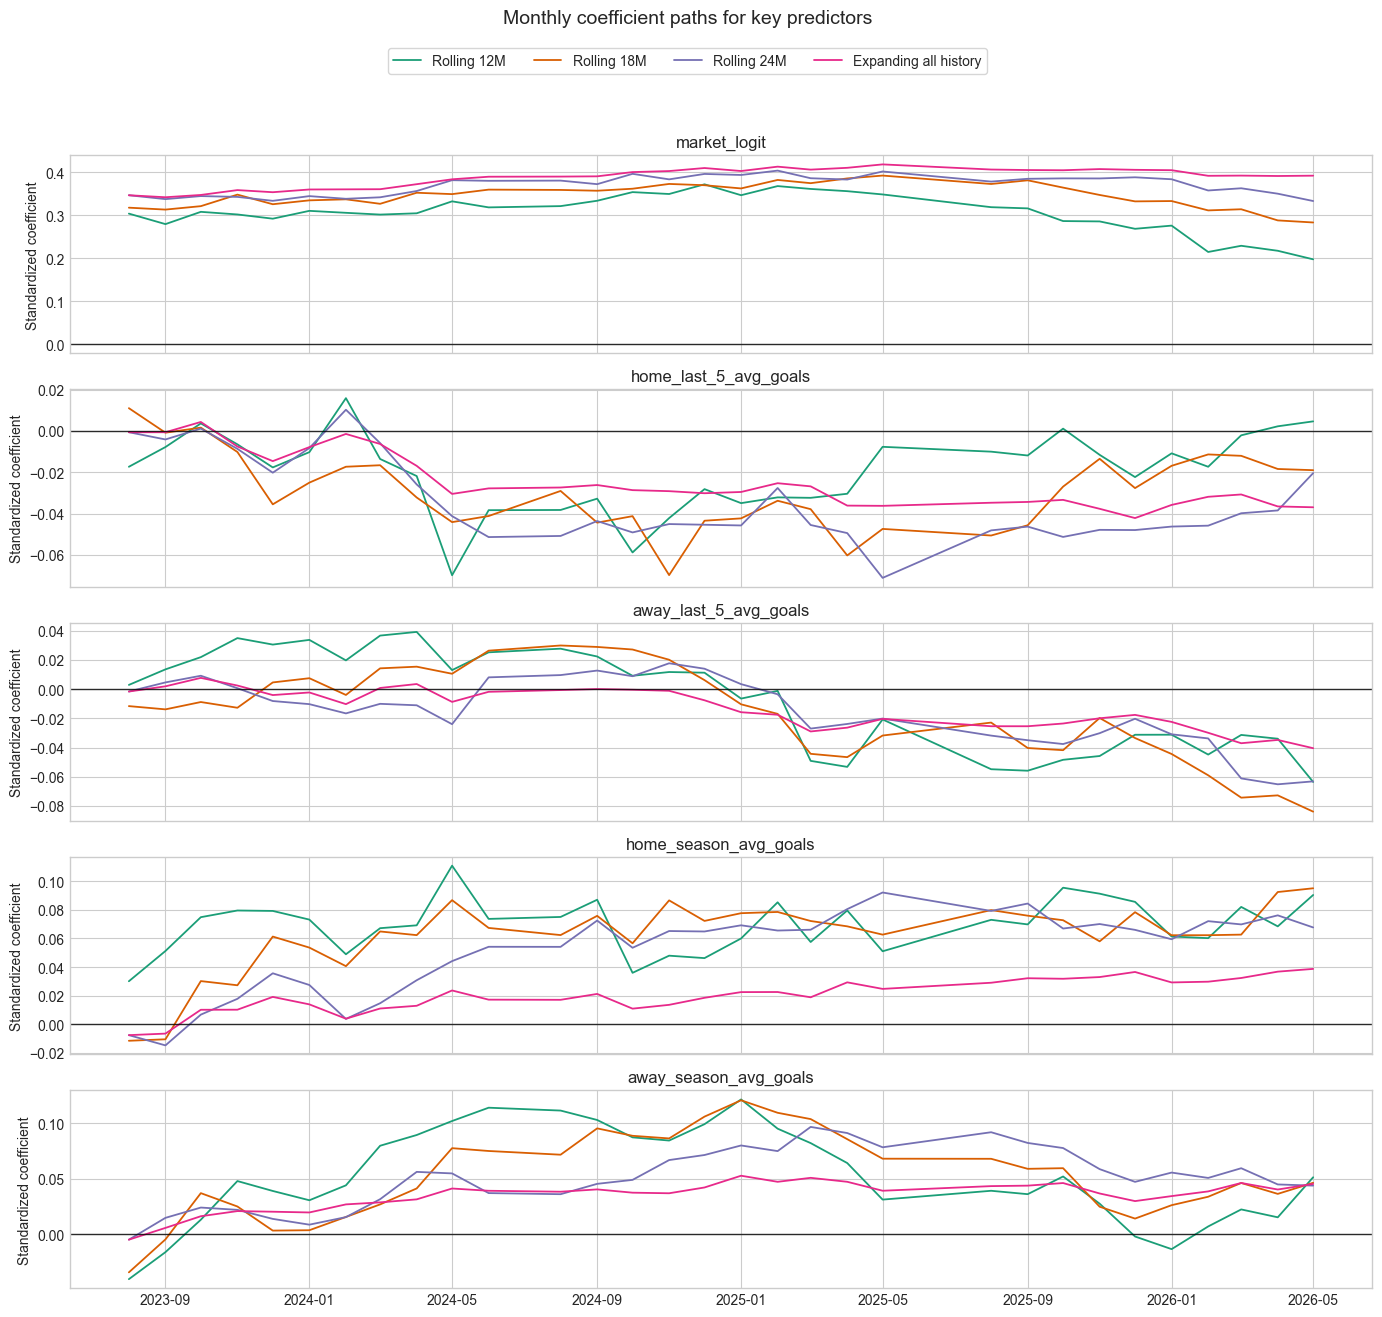

In [7]:
figure, axes = plt.subplots(len(KEY_COEFFICIENTS), 1, figsize=(14, 13), sharex=True)
for axis, coefficient in zip(axes, KEY_COEFFICIENTS):
    subset = coefficient_subset.loc[coefficient_subset["coefficient"].eq(coefficient)]
    for window in WINDOWS:
        window_subset = subset.loc[subset["training_window"].eq(window)]
        axis.plot(
            window_subset["recalibration_month"],
            window_subset["value"],
            linewidth=1.3,
            color=WINDOW_COLORS[window],
            label=WINDOW_LABELS[window],
        )
    add_zero_line(axis)
    axis.set_title(coefficient)
    axis.set_ylabel("Standardized coefficient")
handles, labels = axes[0].get_legend_handles_labels()
plot_panel_legend(figure, handles, labels, y=0.985)
figure.suptitle("Monthly coefficient paths for key predictors", y=1.01, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 6. Economic diagnostics

Execution candidates and bet settlement reuse the existing backtest utilities. Bets are selected with the same fixed threshold as the main model:

```text
EV = model_probability * decimal_odds - 1 >= 3%
```

The closing maximum is included as a non-executable sensitivity and has no CLV benchmark.

In [8]:
candidates = build_execution_candidates(
    monthly_predictions,
    include_closing_prices=True,
    probability_column="model_probability",
)
bets = candidates.loc[candidates["expected_value"].ge(EV_THRESHOLD)].copy()

economic_summary = summarize_bets(bets, ["training_window", "execution_source"])
candidate_summary = (
    candidates.groupby(["training_window", "execution_source"], sort=True)
    .agg(
        candidates=("expected_value", "size"),
        avg_model_probability=("model_probability", "mean"),
        avg_expected_value=("expected_value", "mean"),
    )
    .reset_index()
)
economic_summary = candidate_summary.merge(
    economic_summary, on=["training_window", "execution_source"], how="left"
)
economic_summary = ordered_window_frame(economic_summary)
economic_summary

,training_window,execution_source,candidates,avg_model_probability,avg_expected_value,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,12M,average_preclosing,4221,0.535392,-0.042467,382.0,184.0,48.167539,1.993586,-34.90,-9.136126,-18.898966,0.626715,-1.656973,49.77
1,12M,best_closing,4221,0.535392,0.005812,1487.0,706.0,47.478144,2.161829,-29.09,-1.956288,-7.411836,3.499260,NaN,78.72
2,12M,best_preclosing,4221,0.535392,-0.011956,973.0,492.0,50.565262,2.076136,-1.67,-0.171634,-6.615082,6.271814,-1.923509,37.63
3,12M,bet365,4221,0.535392,-0.035478,488.0,247.0,50.614754,2.063934,-1.03,-0.211066,-9.338702,8.916571,-1.222334,40.63
4,12M,betfair_exchange,2709,0.529209,-0.006158,691.0,328.0,47.467438,2.183690,7.81,1.130246,-7.055886,9.316378,-1.373458,38.79
5,12M,pinnacle,3476,0.534637,-0.018300,651.0,324.0,49.769585,2.050292,-23.74,-3.646697,-11.393320,4.099925,-1.535873,48.57
10,18M,betfair_exchange,2709,0.533490,-0.001049,663.0,346.0,52.187029,2.051207,22.98,3.466063,-4.397165,11.329292,-1.461840,32.29
9,18M,bet365,4221,0.536055,-0.036329,302.0,158.0,52.317881,2.012947,0.15,0.049669,-11.218615,11.317953,-0.934858,22.75
11,18M,pinnacle,3476,0.534286,-0.020667,433.0,227.0,52.424942,1.964781,-9.13,-2.108545,-11.256839,7.039749,-1.568197,31.65
7,18M,best_closing,4221,0.536055,0.004771,1433.0,696.0,48.569435,2.127802,-16.85,-1.175855,-6.670639,4.318929,NaN,58.99


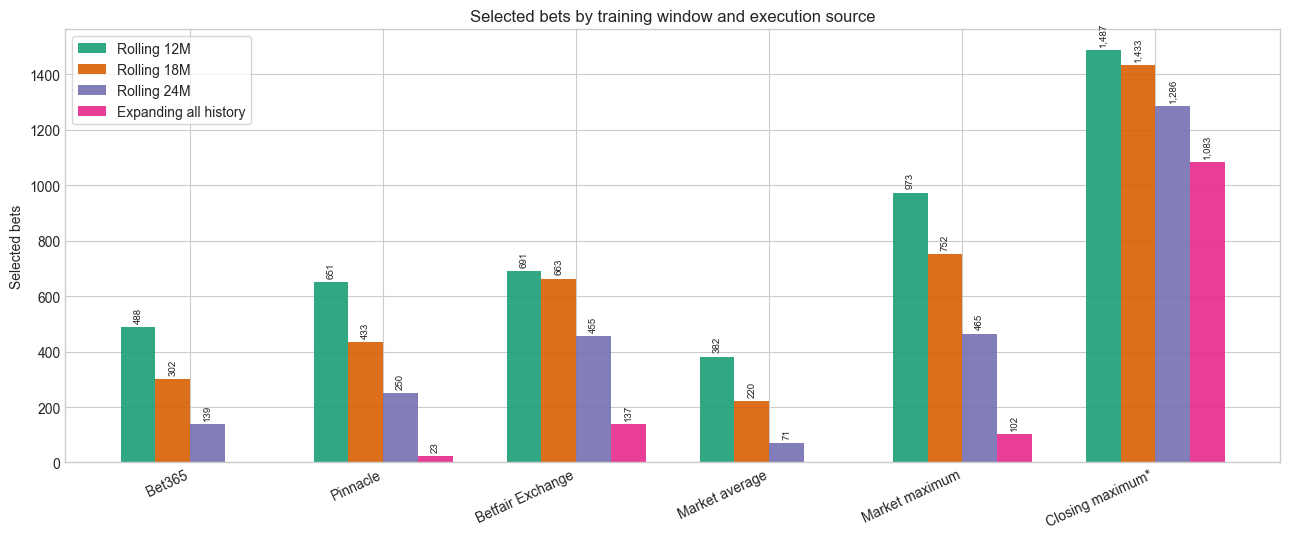

In [9]:
figure, axis = plt.subplots(figsize=(13, 5.5))
bar_width = 0.18
source_x = np.arange(len(SOURCE_ORDER))
for offset_index, window in enumerate(WINDOWS):
    subset = (
        economic_summary.loc[economic_summary["training_window"].eq(window)]
        .set_index("execution_source")
        .reindex(SOURCE_ORDER)
    )
    offset = (offset_index - (len(WINDOWS) - 1) / 2) * bar_width
    bars = axis.bar(
        source_x + offset,
        subset["bets"].fillna(0),
        width=bar_width,
        color=WINDOW_COLORS[window],
        label=WINDOW_LABELS[window],
        alpha=0.9,
    )
    axis.bar_label(
        bars,
        labels=["" if value == 0 or pd.isna(value) else f"{int(value):,}" for value in subset["bets"].fillna(0)],
        padding=3,
        fontsize=7,
        rotation=90,
    )
axis.set_title("Selected bets by training window and execution source")
axis.set_ylabel("Selected bets")
axis.set_xticks(source_x, [SOURCE_LABELS[source] for source in SOURCE_ORDER], rotation=25, ha="right")
axis.legend(loc="best", frameon=True)
figure.tight_layout()
plt.show()

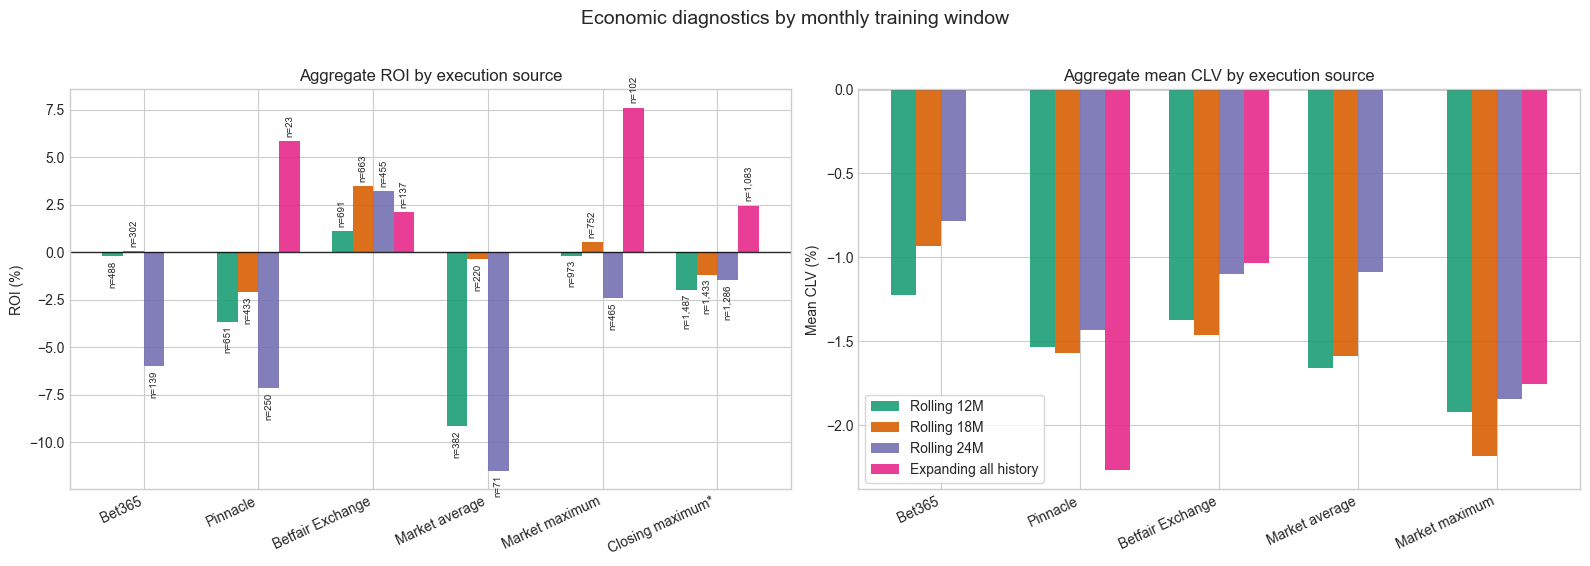

In [10]:
figure, axes = plt.subplots(1, 2, figsize=(16, 5.5))
bar_width = 0.18
source_x = np.arange(len(SOURCE_ORDER))
for offset_index, window in enumerate(WINDOWS):
    subset = (
        economic_summary.loc[economic_summary["training_window"].eq(window)]
        .set_index("execution_source")
        .reindex(SOURCE_ORDER)
    )
    offset = (offset_index - (len(WINDOWS) - 1) / 2) * bar_width
    bars = axes[0].bar(
        source_x + offset,
        subset["roi_pct"],
        width=bar_width,
        color=WINDOW_COLORS[window],
        label=WINDOW_LABELS[window],
        alpha=0.9,
    )
    axes[0].bar_label(
        bars,
        labels=["" if pd.isna(value) else f"n={int(value):,}" for value in subset["bets"]],
        padding=3,
        fontsize=7,
        rotation=90,
    )
clv_sources = [source for source in SOURCE_ORDER if source != "best_closing"]
clv_x = np.arange(len(clv_sources))
for offset_index, window in enumerate(WINDOWS):
    subset = (
        economic_summary.loc[economic_summary["training_window"].eq(window)]
        .set_index("execution_source")
        .reindex(clv_sources)
    )
    offset = (offset_index - (len(WINDOWS) - 1) / 2) * bar_width
    axes[1].bar(
        clv_x + offset,
        subset["mean_clv_pct"],
        width=bar_width,
        color=WINDOW_COLORS[window],
        label=WINDOW_LABELS[window],
        alpha=0.9,
    )
for axis in axes:
    add_zero_line(axis)
    axis.tick_params(axis="x", rotation=25)
axes[0].set_title("Aggregate ROI by execution source")
axes[0].set_ylabel("ROI (%)")
axes[0].set_xticks(source_x, [SOURCE_LABELS[source] for source in SOURCE_ORDER], ha="right")
axes[1].set_title("Aggregate mean CLV by execution source")
axes[1].set_ylabel("Mean CLV (%)")
axes[1].set_xticks(clv_x, [SOURCE_LABELS[source] for source in clv_sources], ha="right")
axes[1].legend(loc="best", frameon=True)
figure.suptitle("Economic diagnostics by monthly training window", y=1.02, fontsize=14)
figure.tight_layout()
plt.show()

## 7. Monthly stability

Monthly ROI, bet counts, cumulative profit, and drawdown are shown for the main executable market-maximum benchmark. This avoids double-counting the same match across multiple venues in the stability plots.

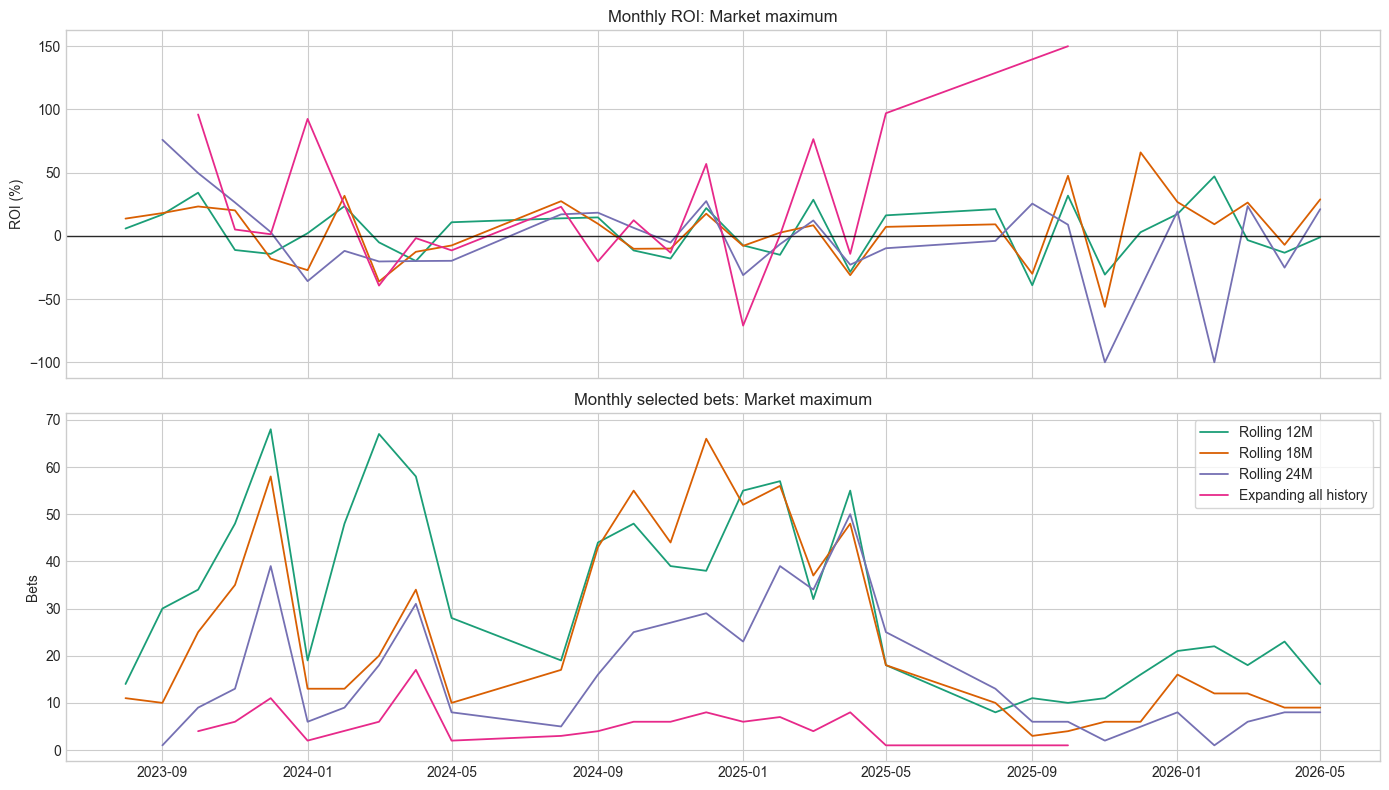

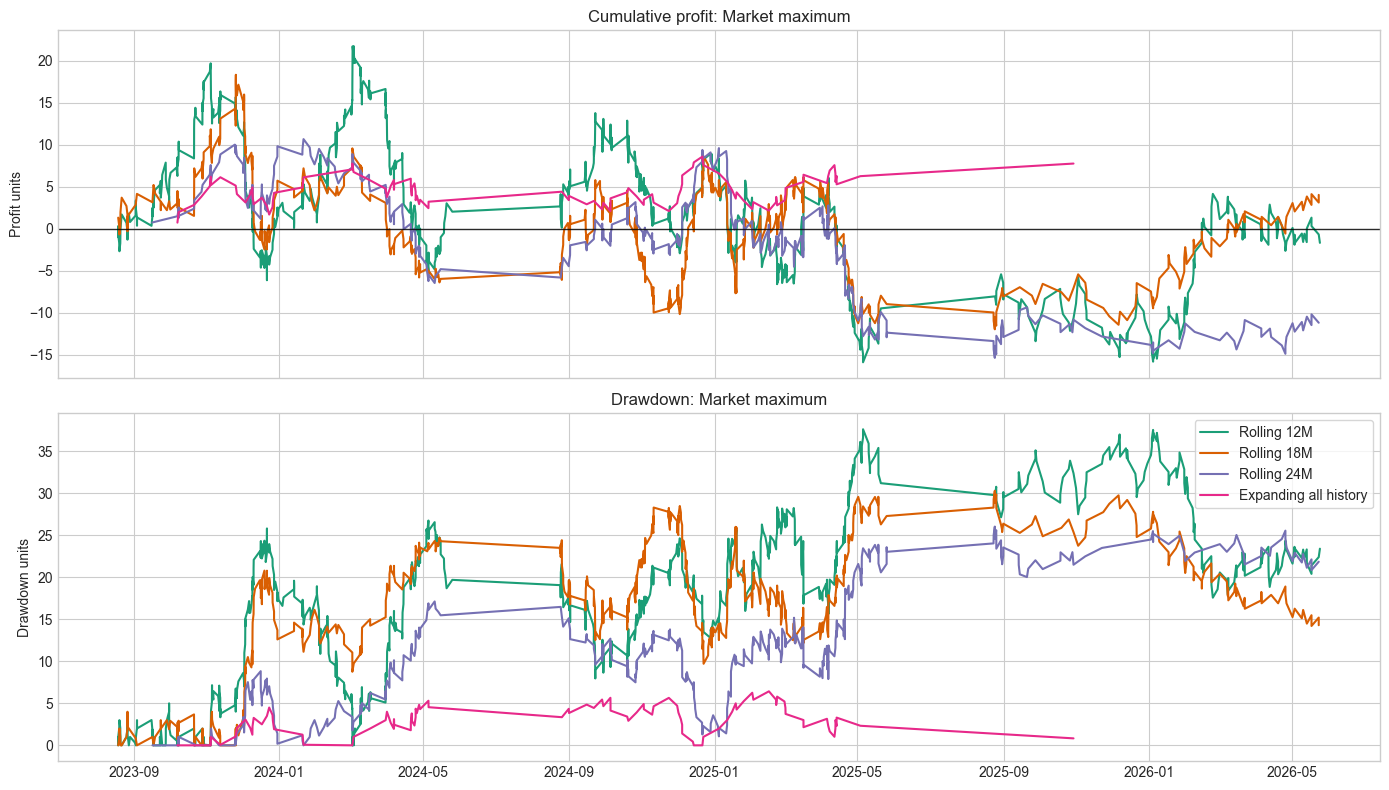

In [11]:
primary_bets = bets.loc[bets["execution_source"].eq(FINAL_EXECUTION_SOURCE)].copy()
monthly_stability = monthly_roi(primary_bets, ["training_window", "execution_source"])

figure, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for window in WINDOWS:
    subset = monthly_stability.loc[monthly_stability["training_window"].eq(window)]
    axes[0].plot(
        subset["month"],
        subset["roi_pct"],
        color=WINDOW_COLORS[window],
        linewidth=1.3,
        label=WINDOW_LABELS[window],
    )
    axes[1].plot(
        subset["month"],
        subset["bets"],
        color=WINDOW_COLORS[window],
        linewidth=1.3,
        label=WINDOW_LABELS[window],
    )
add_zero_line(axes[0])
axes[0].set_title(f"Monthly ROI: {SOURCE_LABELS[FINAL_EXECUTION_SOURCE]}")
axes[0].set_ylabel("ROI (%)")
axes[1].set_title(f"Monthly selected bets: {SOURCE_LABELS[FINAL_EXECUTION_SOURCE]}")
axes[1].set_ylabel("Bets")
axes[1].legend(loc="best", frameon=True)
figure.tight_layout()
plt.show()

figure, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for window in WINDOWS:
    path = primary_bets.loc[primary_bets["training_window"].eq(window)].sort_values("date").copy()
    if path.empty:
        continue
    path["cumulative_profit"] = path["profit"].cumsum()
    path["running_peak"] = path["cumulative_profit"].cummax().clip(lower=0)
    path["drawdown"] = path["running_peak"] - path["cumulative_profit"]
    axes[0].plot(path["date"], path["cumulative_profit"], color=WINDOW_COLORS[window], label=WINDOW_LABELS[window])
    axes[1].plot(path["date"], path["drawdown"], color=WINDOW_COLORS[window], label=WINDOW_LABELS[window])
add_zero_line(axes[0])
axes[0].set_title(f"Cumulative profit: {SOURCE_LABELS[FINAL_EXECUTION_SOURCE]}")
axes[0].set_ylabel("Profit units")
axes[1].set_title(f"Drawdown: {SOURCE_LABELS[FINAL_EXECUTION_SOURCE]}")
axes[1].set_ylabel("Drawdown units")
axes[1].legend(loc="best", frameon=True)
figure.tight_layout()
plt.show()

## 8. Season and league robustness

The next diagnostics check whether a window's result is dominated by one season or league. These are robustness diagnostics, not a search for a league-specific strategy.

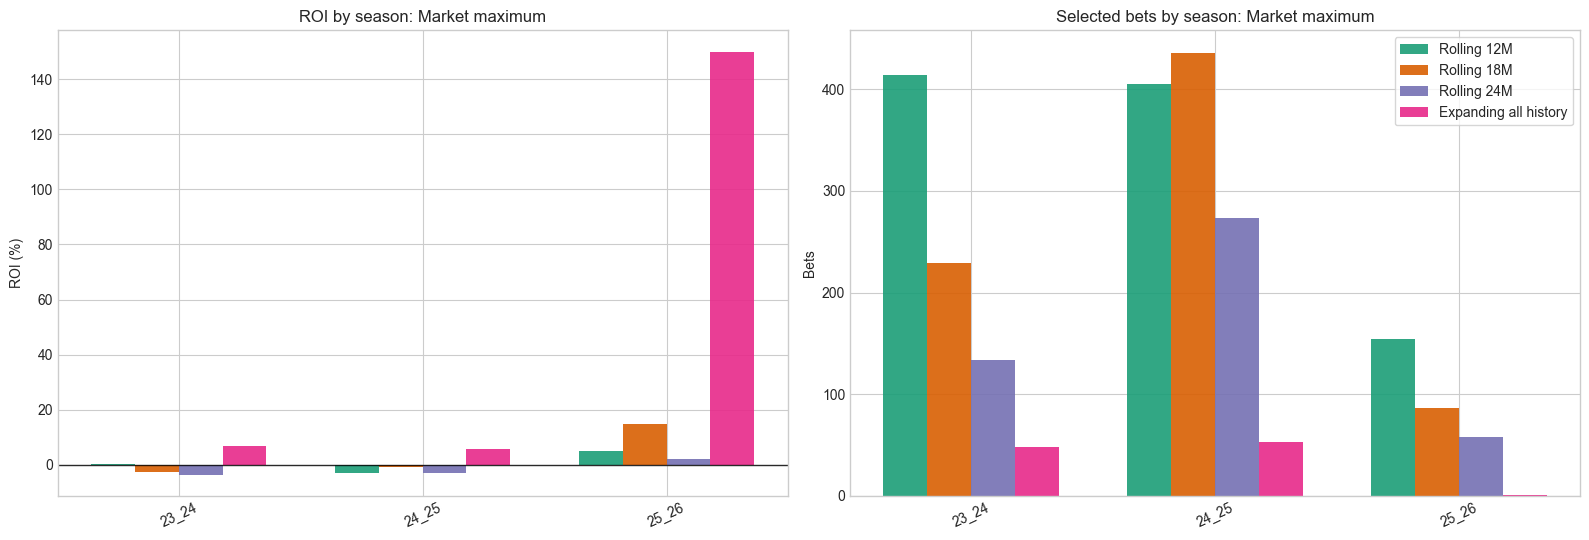

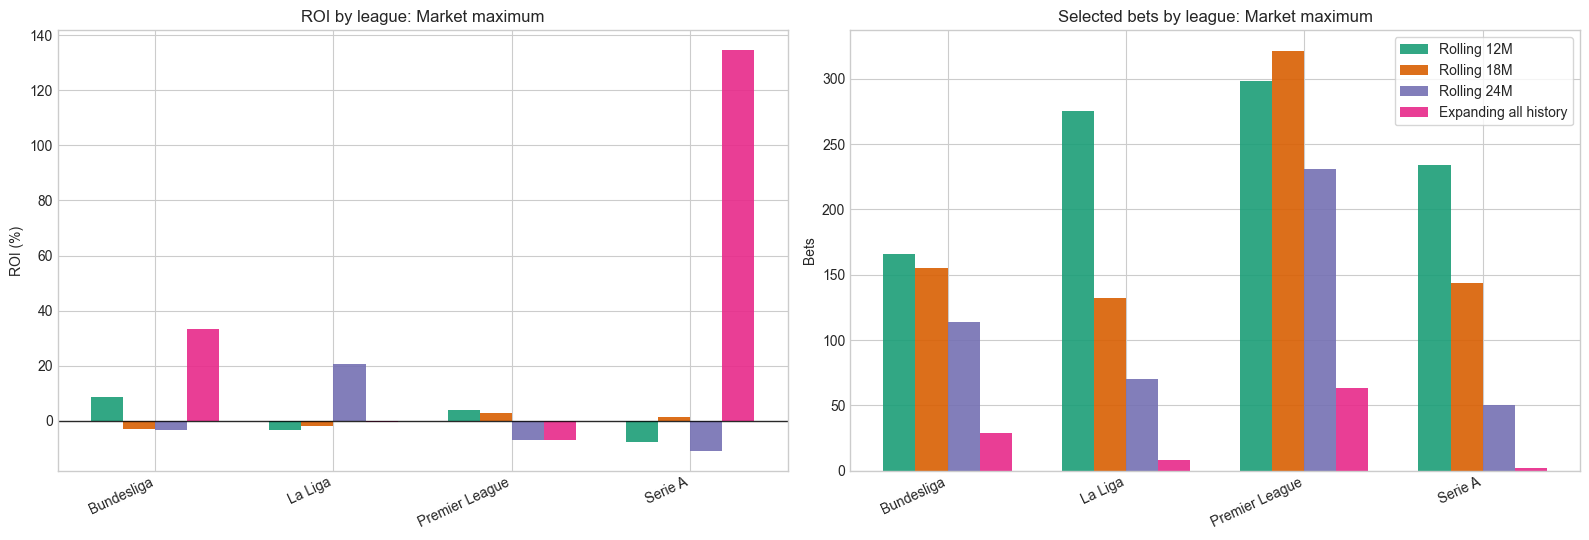

In [12]:
season_summary = summarize_bets(primary_bets, ["training_window", "season"])
league_summary = summarize_bets(primary_bets, ["training_window", "league"])

figure, axes = plt.subplots(1, 2, figsize=(16, 5.5))
season_x = np.arange(len(season_order))
bar_width = 0.18
for offset_index, window in enumerate(WINDOWS):
    subset = season_summary.loc[season_summary["training_window"].eq(window)].set_index("season").reindex(season_order)
    offset = (offset_index - (len(WINDOWS) - 1) / 2) * bar_width
    axes[0].bar(season_x + offset, subset["roi_pct"], width=bar_width, color=WINDOW_COLORS[window], label=WINDOW_LABELS[window], alpha=0.9)
    axes[1].bar(season_x + offset, subset["bets"], width=bar_width, color=WINDOW_COLORS[window], label=WINDOW_LABELS[window], alpha=0.9)
add_zero_line(axes[0])
axes[0].set_title(f"ROI by season: {SOURCE_LABELS[FINAL_EXECUTION_SOURCE]}")
axes[0].set_ylabel("ROI (%)")
axes[1].set_title(f"Selected bets by season: {SOURCE_LABELS[FINAL_EXECUTION_SOURCE]}")
axes[1].set_ylabel("Bets")
for axis in axes:
    axis.set_xticks(season_x, season_order, rotation=25)
axes[1].legend(loc="best", frameon=True)
figure.tight_layout()
plt.show()

league_order = sorted(primary_bets["league"].unique())
league_x = np.arange(len(league_order))
figure, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for offset_index, window in enumerate(WINDOWS):
    subset = league_summary.loc[league_summary["training_window"].eq(window)].set_index("league").reindex(league_order)
    offset = (offset_index - (len(WINDOWS) - 1) / 2) * bar_width
    axes[0].bar(league_x + offset, subset["roi_pct"], width=bar_width, color=WINDOW_COLORS[window], label=WINDOW_LABELS[window], alpha=0.9)
    axes[1].bar(league_x + offset, subset["bets"], width=bar_width, color=WINDOW_COLORS[window], label=WINDOW_LABELS[window], alpha=0.9)
add_zero_line(axes[0])
axes[0].set_title(f"ROI by league: {SOURCE_LABELS[FINAL_EXECUTION_SOURCE]}")
axes[0].set_ylabel("ROI (%)")
axes[1].set_title(f"Selected bets by league: {SOURCE_LABELS[FINAL_EXECUTION_SOURCE]}")
axes[1].set_ylabel("Bets")
for axis in axes:
    axis.set_xticks(league_x, league_order, rotation=25, ha="right")
axes[1].legend(loc="best", frameon=True)
figure.tight_layout()
plt.show()

## 9. Market benchmark decomposition

This section decomposes the all-history monthly result into three probability signals evaluated on the same matches:

1. **Raw market probability**: the no-vig market-implied probability, without model fitting.
2. **Monthly market-only recalibration**: monthly all-history logistic recalibration using only `market_logit`.
3. **Monthly full model**: monthly all-history logistic model using the main market-anchored feature set.

This answers two separate questions:

- Does monthly recalibration of the market improve the raw market probability?
- Do team-form features add incremental value after market-only recalibration?

In [13]:
benchmark_predictions = []

raw_market = monthly_predictions.loc[
    monthly_predictions["training_window"].eq("all_history")
].copy()
raw_market["benchmark_signal"] = "Raw market probability"
raw_market["benchmark_probability"] = raw_market["market_over_probability"]
benchmark_predictions.append(raw_market)

market_only_predictions, _ = run_pooled_monthly_recalibration_walk_forward(
    analysis_matches,
    "all_history",
    l2=L2,
    model_name="Monthly market-only recalibration",
    feature_columns=["market_logit"],
)
market_only_predictions = market_only_predictions.loc[
    market_only_predictions["recalibration_month"].isin(common_months)
].copy()
market_only_predictions["benchmark_signal"] = "Monthly market-only recalibration"
market_only_predictions["benchmark_probability"] = market_only_predictions["model_probability"]
benchmark_predictions.append(market_only_predictions)

full_model = monthly_predictions.loc[
    monthly_predictions["training_window"].eq("all_history")
].copy()
full_model["benchmark_signal"] = "Monthly full model"
full_model["benchmark_probability"] = full_model["model_probability"]
benchmark_predictions.append(full_model)

benchmark_predictions = pd.concat(benchmark_predictions, ignore_index=True)
BENCHMARK_ORDER = [
    "Raw market probability",
    "Monthly market-only recalibration",
    "Monthly full model",
]
BENCHMARK_COLORS = {
    "Raw market probability": "#1B9E77",
    "Monthly market-only recalibration": "#7570B3",
    "Monthly full model": "#E7298A",
}
benchmark_predictions["benchmark_signal"] = pd.Categorical(
    benchmark_predictions["benchmark_signal"],
    categories=BENCHMARK_ORDER,
    ordered=True,
)

benchmark_predictive = probability_performance(
    benchmark_predictions,
    probability_column="benchmark_probability",
    group_by=["benchmark_signal"],
).sort_values("benchmark_signal")
benchmark_predictive

,benchmark_signal,observations,brier_score,log_loss,accuracy,calibration_intercept,calibration_slope,mean_probability,event_rate
2,Monthly full model,4221,0.237428,0.667383,0.593935,0.035423,0.972892,0.531549,0.539209
1,Monthly market-only recalibration,4221,0.237441,0.667409,0.591803,0.034707,0.976741,0.531612,0.539209
0,Raw market probability,4221,0.237233,0.666989,0.593224,0.023676,1.105543,0.530709,0.539209


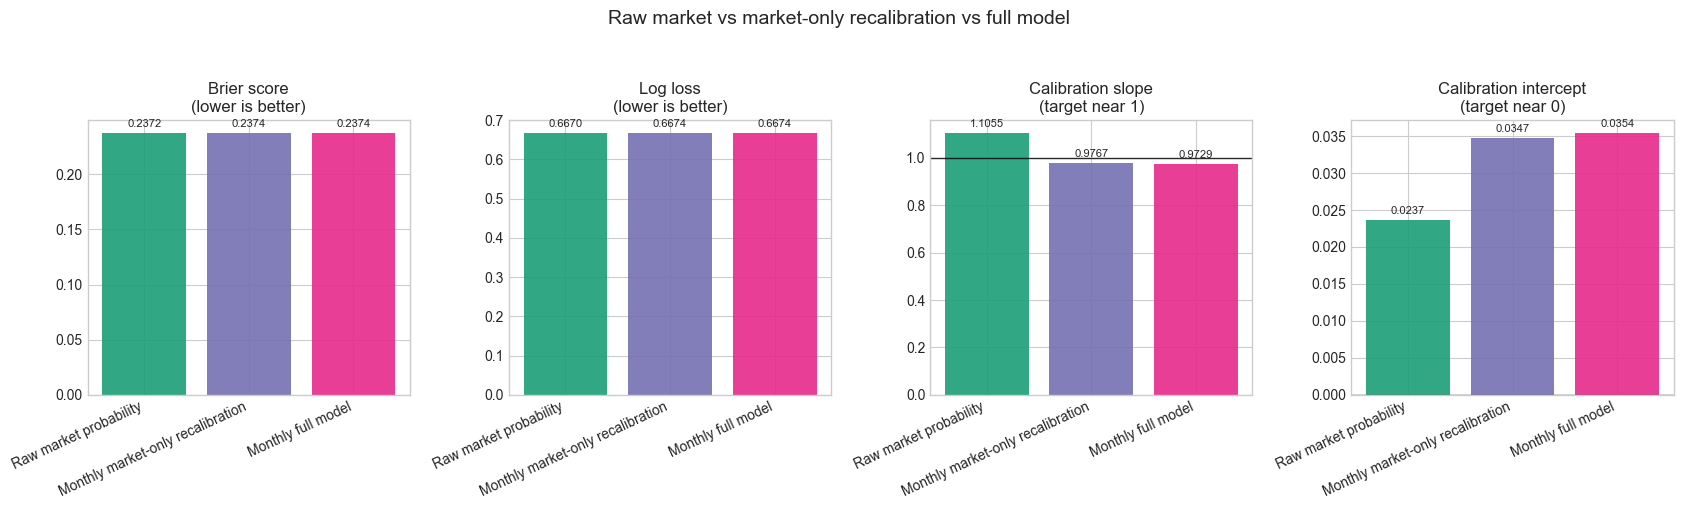

In [14]:
figure, axes = plt.subplots(1, 4, figsize=(17, 4.8))
benchmark_metric_specs = [
    ("brier_score", "Brier score\n(lower is better)"),
    ("log_loss", "Log loss\n(lower is better)"),
    ("calibration_slope", "Calibration slope\n(target near 1)"),
    ("calibration_intercept", "Calibration intercept\n(target near 0)"),
]
for axis, (metric, title) in zip(axes, benchmark_metric_specs):
    values = benchmark_predictive.set_index("benchmark_signal").reindex(BENCHMARK_ORDER)[metric]
    bars = axis.bar(
        np.arange(len(BENCHMARK_ORDER)),
        values,
        color=[BENCHMARK_COLORS[label] for label in BENCHMARK_ORDER],
        alpha=0.9,
    )
    if metric == "calibration_slope":
        axis.axhline(1, color="black", linewidth=1, alpha=0.8)
    elif metric == "calibration_intercept":
        add_zero_line(axis)
    axis.bar_label(bars, labels=[f"{value:.4f}" for value in values], padding=3, fontsize=8)
    axis.set_title(title)
    axis.set_xticks(np.arange(len(BENCHMARK_ORDER)), BENCHMARK_ORDER, rotation=25, ha="right")
figure.suptitle("Raw market vs market-only recalibration vs full model", y=1.05, fontsize=14)
figure.tight_layout()
plt.show()

In [15]:
benchmark_candidate_frames = []
for signal_name, signal_data in benchmark_predictions.groupby("benchmark_signal", sort=False):
    signal_candidates = build_execution_candidates(
        signal_data,
        include_closing_prices=True,
        probability_column="benchmark_probability",
    )
    signal_candidates["benchmark_signal"] = signal_name
    benchmark_candidate_frames.append(signal_candidates)
benchmark_candidates = pd.concat(benchmark_candidate_frames, ignore_index=True)
benchmark_bets = benchmark_candidates.loc[
    benchmark_candidates["expected_value"].ge(EV_THRESHOLD)
].copy()

benchmark_economic = summarize_bets(
    benchmark_bets,
    ["benchmark_signal", "execution_source"],
)
benchmark_candidate_summary = (
    benchmark_candidates.groupby(["benchmark_signal", "execution_source"], sort=True)
    .agg(
        candidates=("expected_value", "size"),
        avg_probability=("benchmark_probability", "mean"),
        avg_expected_value=("expected_value", "mean"),
    )
    .reset_index()
)
benchmark_economic = benchmark_candidate_summary.merge(
    benchmark_economic,
    on=["benchmark_signal", "execution_source"],
    how="left",
)
benchmark_economic["benchmark_signal"] = pd.Categorical(
    benchmark_economic["benchmark_signal"],
    categories=BENCHMARK_ORDER,
    ordered=True,
)
benchmark_economic["execution_source"] = pd.Categorical(
    benchmark_economic["execution_source"],
    categories=SOURCE_ORDER,
    ordered=True,
)
benchmark_economic = benchmark_economic.sort_values(["execution_source", "benchmark_signal"])
benchmark_economic

,benchmark_signal,execution_source,candidates,avg_probability,avg_expected_value,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
15,Raw market probability,bet365,4221,0.530709,-0.045538,1.0,1.0,100.000000,3.200000,2.20,220.000000,NaN,NaN,0.000000,0.00
9,Monthly market-only recalibration,bet365,4221,0.531612,-0.047319,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Monthly full model,bet365,4221,0.531549,-0.047523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,Raw market probability,pinnacle,3476,0.528031,-0.030711,1.0,1.0,100.000000,1.920000,0.92,92.000000,NaN,NaN,0.000000,0.00
11,Monthly market-only recalibration,pinnacle,3476,0.528479,-0.033633,7.0,7.0,100.000000,1.440000,3.08,44.000000,26.700320,61.299680,0.000000,0.00
5,Monthly full model,pinnacle,3476,0.528621,-0.033448,23.0,15.0,65.217391,1.733043,1.35,5.869565,-27.626852,39.365982,-2.268662,3.68
16,Raw market probability,betfair_exchange,2709,0.526018,-0.015370,22.0,10.0,45.454545,2.745909,4.76,21.636364,-35.981775,79.254503,-2.168744,3.00
10,Monthly market-only recalibration,betfair_exchange,2709,0.527611,-0.016281,57.0,29.0,50.877193,1.956140,0.17,0.298246,-25.895468,26.491959,2.074797,9.16
4,Monthly full model,betfair_exchange,2709,0.527424,-0.016813,137.0,76.0,55.474453,1.857372,2.93,2.138686,-13.659387,17.936760,-1.032304,8.76
12,Raw market probability,average_preclosing,4221,0.530709,-0.052487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


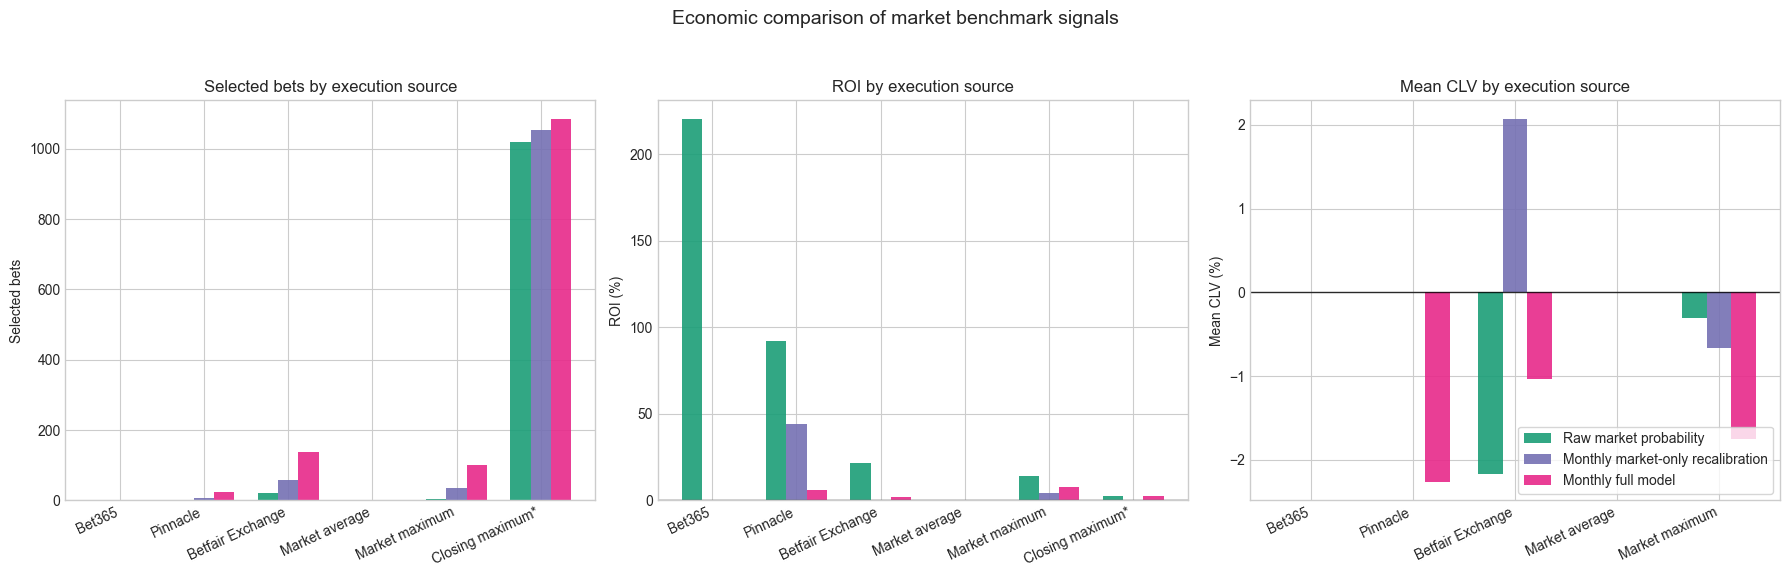

In [16]:
figure, axes = plt.subplots(1, 3, figsize=(18, 5.5))
bar_width = 0.24
source_x = np.arange(len(SOURCE_ORDER))
for offset_index, signal_name in enumerate(BENCHMARK_ORDER):
    subset = (
        benchmark_economic.loc[benchmark_economic["benchmark_signal"].eq(signal_name)]
        .set_index("execution_source")
        .reindex(SOURCE_ORDER)
    )
    offset = (offset_index - (len(BENCHMARK_ORDER) - 1) / 2) * bar_width
    axes[0].bar(
        source_x + offset,
        subset["bets"].fillna(0),
        width=bar_width,
        color=BENCHMARK_COLORS[signal_name],
        label=signal_name,
        alpha=0.9,
    )
    axes[1].bar(
        source_x + offset,
        subset["roi_pct"],
        width=bar_width,
        color=BENCHMARK_COLORS[signal_name],
        label=signal_name,
        alpha=0.9,
    )

clv_sources = [source for source in SOURCE_ORDER if source != "best_closing"]
clv_x = np.arange(len(clv_sources))
for offset_index, signal_name in enumerate(BENCHMARK_ORDER):
    subset = (
        benchmark_economic.loc[benchmark_economic["benchmark_signal"].eq(signal_name)]
        .set_index("execution_source")
        .reindex(clv_sources)
    )
    offset = (offset_index - (len(BENCHMARK_ORDER) - 1) / 2) * bar_width
    axes[2].bar(
        clv_x + offset,
        subset["mean_clv_pct"],
        width=bar_width,
        color=BENCHMARK_COLORS[signal_name],
        label=signal_name,
        alpha=0.9,
    )

axes[0].set_title("Selected bets by execution source")
axes[0].set_ylabel("Selected bets")
axes[1].set_title("ROI by execution source")
axes[1].set_ylabel("ROI (%)")
axes[2].set_title("Mean CLV by execution source")
axes[2].set_ylabel("Mean CLV (%)")
for axis in axes[:2]:
    axis.set_xticks(source_x, [SOURCE_LABELS[source] for source in SOURCE_ORDER], rotation=25, ha="right")
for axis in axes[1:]:
    add_zero_line(axis)
axes[2].set_xticks(clv_x, [SOURCE_LABELS[source] for source in clv_sources], rotation=25, ha="right")
axes[2].legend(loc="best", frameon=True)
figure.suptitle("Economic comparison of market benchmark signals", y=1.04, fontsize=14)
figure.tight_layout()
plt.show()

## 10. Final comparison table

The final compact table uses the common overlapping test months and the main executable market-maximum benchmark. This keeps the comparison fair and avoids double-counting the same match across multiple execution venues.

In [17]:
primary_economic = economic_summary.loc[
    economic_summary["execution_source"].eq(FINAL_EXECUTION_SOURCE)
].copy()
final_table = predictive_summary.merge(
    primary_economic[
        [
            "training_window",
            "bets",
            "roi_pct",
            "roi_95_low_pct",
            "roi_95_high_pct",
            "mean_clv_pct",
            "max_drawdown_units",
        ]
    ],
    on="training_window",
    how="left",
)
final_table = final_table[
    [
        "training_window",
        "recalibration_months",
        "avg_training_matches",
        "total_test_matches",
        "brier_score",
        "log_loss",
        "calibration_slope",
        "bets",
        "roi_pct",
        "roi_95_low_pct",
        "roi_95_high_pct",
        "mean_clv_pct",
        "max_drawdown_units",
    ]
]
final_table = ordered_window_frame(final_table)
final_table

,training_window,recalibration_months,avg_training_matches,total_test_matches,brier_score,log_loss,calibration_slope,bets,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,12M,31,1412.354839,4221,0.238216,0.669081,1.030952,973.0,-0.171634,-6.615082,6.271814,-1.923509,37.63
1,18M,31,2092.193548,4221,0.237877,0.668360,1.001575,752.0,0.537234,-6.494541,7.569009,-2.185179,30.30
2,24M,31,2814.838710,4221,0.237697,0.667930,0.983381,465.0,-2.404301,-11.110669,6.302067,-1.841692,26.04
3,all_history,31,4780.967742,4221,0.237428,0.667383,0.972892,102.0,7.617647,-9.882938,25.118233,-1.752577,6.43


## 11. Interpretation and limitations

**Main robustness conclusion.**  
The monthly recalibration experiment does not overturn the project's main market-efficiency conclusion. Changing the amount of training history changes bet frequency, coefficient smoothness, and realized ROI, but no window provides clean evidence of a production-ready edge once CLV, uncertainty, drawdown, and sample size are considered.

**Predictive diagnostics.**  
The expanding `all_history` window has the best aggregate predictive metrics on the common overlapping period: Brier/log loss of approximately **0.2374 / 0.6674**. The rolling windows are slightly worse, with shorter windows generally noisier. Calibration slopes are all close to one, but `all_history` is slightly below one, suggesting mild under/over-dispersion relative to the ideal calibration line depending on period. Overall, the differences are small; the model remains market-anchored and hard to improve materially by changing only the training window.

**Coefficient stability.**  
The expanding `all_history` window should be expected to produce smoother coefficients because each monthly refit changes less. The 12M window adapts faster but uses many fewer observations per fold, so coefficient paths are more sensitive to recent noise. This is the core recency-versus-sample-size trade-off; it should not be treated as a free parameter to optimize from realized ROI.

**Economic diagnostics.**  
For the main executable market-maximum benchmark (`best_preclosing`), selected bets decline sharply as the training window grows: approximately **973** bets for 12M, **752** for 18M, **465** for 24M, and only **102** for `all_history`. The `all_history` ROI is positive at about **+7.6%**, but the sample is much smaller and the confidence interval is wide. The rolling windows have many more bets but weaker or negative ROI. Mean CLV is negative for all windows in the main benchmark, so the realized ROI results should be interpreted cautiously.

**Why does `all_history` stop betting after October 2025'**  
For `best_preclosing`, yes: `all_history` places one selected bet in **October 2025** and then no further selected bets through May 2026. This is not a data or plotting error. The model still creates candidates each month, but after October 2025 their expected values do not exceed the fixed **3% EV threshold**. In the reconstructed diagnostics, the maximum `all_history` EV for `best_preclosing` after October 2025 remains below 3% in every later month. The expanding model is more conservative/smoother, so its probabilities rarely move far enough away from market prices to trigger bets. Note that this statement is specific to `best_preclosing`; `all_history` still places later bets in some other execution-source diagnostics such as Betfair Exchange and the non-executable closing-maximum sensitivity.


**Market benchmark decomposition.**  
The decomposition strengthens the market-efficiency interpretation. On the common overlapping period, the raw no-vig market probability has the best predictive metrics among the three benchmark signals, with Brier/log loss of approximately **0.2372 / 0.6670**. Monthly market-only recalibration is slightly worse (**0.2374 / 0.6674**), and the monthly full model is also slightly worse (**0.2374 / 0.6674**). This suggests that neither monthly recalibration of the market logit nor adding the simple team-form features provides robust incremental predictive value over the raw market benchmark. Economically, the raw market signal selects very few bets at the fixed 3% threshold, so its high realized ROI is not strong evidence of tradable edge.

**Season and league robustness.**  
The season/league plots should be read as concentration checks. A convincing robustness result would not depend on one season, one league, or one execution source. The current evidence remains mixed and noisy, especially because selected-bet counts differ materially by window.

**Decision.**  
The two-season intuition remains defensible, but notebook 08 shows that training-window length is a meaningful researcher degree of freedom. I would not choose a new preferred window based on ROI alone. The most conservative reading is that the market-efficiency conclusion is broadly stable: reasonable monthly recalibration windows do not reveal a robust, executable edge. The result is useful for the public project because it makes the training-window assumption explicit and stress-tests it without changing the model, features, EV threshold, or execution logic.